# CSE 413: Simulation and Modeling Lab
**Lab 06: Hypothesis Testing — One-Sample and Two-Sample t-Tests**  
**Academic Level / Term:** 4/1 | **Credit:** 1.5  
**Course Instructor:** Afroja Ahmed Smrity  
**Student Name:** Azhar  
**Student ID:** 1120  


---


## 0. Import Required Scientific Libraries

We utilize NumPy for numerical operations and array manipulations, SciPy (`scipy.stats`) for probability distributions and statistical hypothesis testing, and Matplotlib for data visualization.


In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Display formatting
np.set_printoptions(precision=4, suppress=True)
print("Libraries imported successfully.")


Libraries imported successfully.


---
# Question 1: One-Sample t-Test (Lab Experiment Completion Time)

### Problem Statement
A university claims that the average time students spend completing a laboratory experiment is **45 minutes**. A random sample of 8 students recorded the following completion times:
- **Sample Data:** `[42, 47, 44, 49, 46, 43, 48, 45]` minutes
- **Tasks:**
  1. Calculate the $t$-statistic and $p$-value.
  2. Determine whether the population mean is significantly different from the claimed mean at a **0.05 significance level**.
  3. Interpret and visualize the result.


### 1.1 Hypothesis Formulation

We formulate a two-tailed one-sample $t$-test against the claimed population mean $\mu_0 = 45$:
- **Null Hypothesis ($H_0$):** $\mu = 45$  
  *The true average time students spend completing the laboratory experiment is equal to 45 minutes.*
- **Alternative Hypothesis ($H_1$):** $\mu \neq 45$  
  *The true average time students spend completing the laboratory experiment is significantly different from 45 minutes.*
- **Significance Level:** $\alpha = 0.05$


In [13]:
# Q1: Initialize sample data and parameters
data_q1 = np.array([42, 47, 44, 49, 46, 43, 48, 45], dtype=float)
mu_0 = 45.0
alpha_q1 = 0.05
n_q1 = len(data_q1)

print(f"Sample Observations (n = {n_q1}): {data_q1}")
print(f"Claimed Population Mean (μ0): {mu_0} minutes")
print(f"Significance Level (alpha): {alpha_q1}")


Sample Observations (n = 8): [42. 47. 44. 49. 46. 43. 48. 45.]
Claimed Population Mean (μ0): 45.0 minutes
Significance Level (alpha): 0.05


In [ ]:
# Compute descriptive statistics
mean_q1 = np.mean(data_q1)
var_q1 = np.var(data_q1, ddof=1)
std_q1 = np.std(data_q1, ddof=1)
se_q1 = std_q1 / np.sqrt(n_q1)
df_q1 = n_q1 - 1

print("--- Question 1: Sample Statistics ---")
print(f"Sample Size (n): {n_q1}")
print(f"Sample Mean (x̄): {mean_q1:.4f} minutes")
print(f"Sample Variance (s^2, ddof=1): {var_q1:.4f}")
print(f"Sample Standard Deviation (s): {std_q1:.4f} minutes")
print(f"Standard Error of Mean (SE): {se_q1:.4f}")
print(f"Degrees of Freedom (df = n - 1): {df_q1}")


--- Question 1: Sample Statistics ---
Sample Size (n): 8
Sample Mean (x̄): 45.5000 minutes
Sample Variance (s^2, ddof=1): 6.0000
Sample Standard Deviation (s): 2.4495 minutes
Standard Error of Mean (SE): 0.8660
Degrees of Freedom (df = n - 1): 7


In [4]:
# Analytical t-statistic and two-tailed p-value
t_stat_q1_manual = (mean_q1 - mu_0) / se_q1
p_val_q1_manual = 2 * (1 - stats.t.cdf(abs(t_stat_q1_manual), df_q1))

# Critical t-value for two-tailed alpha = 0.05
t_crit_q1 = stats.t.ppf(1 - alpha_q1 / 2, df_q1)

# SciPy verification
t_stat_q1_scipy, p_val_q1_scipy = stats.ttest_1samp(data_q1, mu_0)

# 95% Confidence Interval of the true mean
ci_q1 = stats.t.interval(0.95, df_q1, loc=mean_q1, scale=se_q1)

print("--- Question 1: Inferential Results ---")
print(f"Manual t-Statistic: {t_stat_q1_manual:.4f}")
print(f"SciPy t-Statistic:  {t_stat_q1_scipy:.4f}")
print(f"Critical t-Value (±t_0.025, 7): ±{t_crit_q1:.4f}")
print(f"Manual Two-Tailed p-Value: {p_val_q1_manual:.4f}")
print(f"SciPy Two-Tailed p-Value:  {p_val_q1_scipy:.4f}")
print(f"95% Confidence Interval for μ: [{ci_q1[0]:.4f}, {ci_q1[1]:.4f}] minutes")


--- Question 1: Inferential Results ---
Manual t-Statistic: 0.5774
SciPy t-Statistic:  0.5774
Critical t-Value (±t_0.025, 7): ±2.3646
Manual Two-Tailed p-Value: 0.5818
SciPy Two-Tailed p-Value:  0.5818
95% Confidence Interval for μ: [43.4522, 47.5478] minutes


In [5]:
print("=== Question 1: Decision & Conclusion ===")
if p_val_q1_scipy < alpha_q1:
    decision_q1 = "Reject the null hypothesis (H0)."
    interpretation_q1 = (
        f"At the {alpha_q1*100:.0f}% significance level, we reject the null hypothesis (t({df_q1}) = {t_stat_q1_scipy:.2f}, p = {p_val_q1_scipy:.4f}). "
        f"There is sufficient statistical evidence that the true average completion time differs from the claimed {mu_0} minutes."
    )
else:
    decision_q1 = "Fail to reject the null hypothesis (H0)."
    interpretation_q1 = (
        f"At the {alpha_q1*100:.0f}% significance level, we fail to reject the null hypothesis (t({df_q1}) = {t_stat_q1_scipy:.2f}, p = {p_val_q1_scipy:.4f}). "
        f"There is no statistically significant evidence to reject the university's claim. "
        f"The sample mean of {mean_q1:.2f} minutes is consistent with the claimed average of {mu_0} minutes."
    )

print(f"Decision: {decision_q1}")
print(f"\nPlain-English Interpretation:\n{interpretation_q1}")


=== Question 1: Decision & Conclusion ===
Decision: Fail to reject the null hypothesis (H0).

Plain-English Interpretation:
At the 5% significance level, we fail to reject the null hypothesis (t(7) = 0.58, p = 0.5818). There is no statistically significant evidence to reject the university's claim. The sample mean of 45.50 minutes is consistent with the claimed average of 45.0 minutes.


### 1.5 Visualization for Question 1

We visualize the sample completion times, the sample mean with its 95% confidence interval, and the university's claimed benchmark mean (45 minutes).


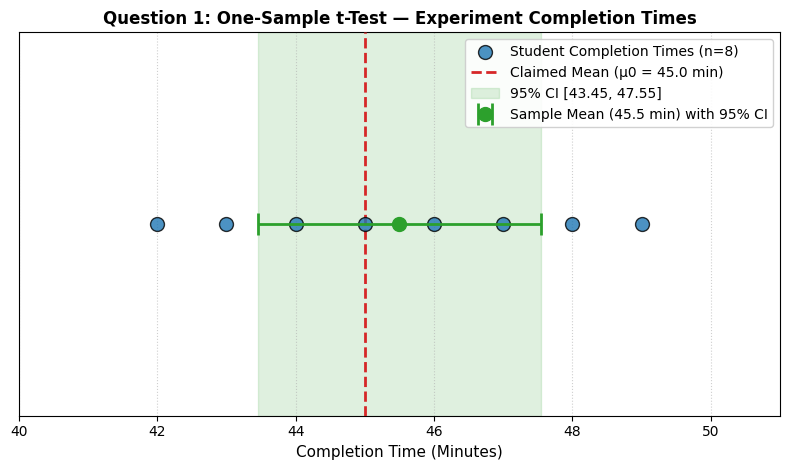

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.8))

# Scatter of sample observations
ax.scatter(data_q1, np.zeros_like(data_q1), color='#1f77b4', s=100, alpha=0.8, edgecolors='black', label='Student Completion Times (n=8)', zorder=4)

# Error bar showing Sample Mean and 95% Confidence Interval
me_q1 = t_crit_q1 * se_q1
ax.errorbar(mean_q1, 0, xerr=me_q1, fmt='o', color='#2ca02c', markersize=10, capsize=8, capthick=2, elinewidth=2, label=f'Sample Mean ({mean_q1:.1f} min) with 95% CI', zorder=5)

# Benchmark claimed line
ax.axvline(mu_0, color='#d62728', linestyle='--', linewidth=2, label=f'Claimed Mean (μ0 = {mu_0} min)', zorder=3)

# Shaded 95% CI region
ax.axvspan(ci_q1[0], ci_q1[1], color='#2ca02c', alpha=0.15, label=f'95% CI [{ci_q1[0]:.2f}, {ci_q1[1]:.2f}]')

ax.set_title('Question 1: One-Sample t-Test — Experiment Completion Times', fontsize=12, fontweight='bold')
ax.set_xlabel('Completion Time (Minutes)', fontsize=11)
ax.set_yticks([])
ax.set_xlim(40, 51)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


---
# Question 2: Two-Sample Pooled t-Test (Algorithm Comparison)

### Problem Statement
An experiment compares the processing time of two algorithms. The measured processing times (in milliseconds) are:
- **Algorithm A:** `[42, 45, 39, 44, 41, 43, 40]`
- **Algorithm B:** `[48, 51, 46, 49, 50, 47, 52]`

Assume **equal population variances** ($\sigma_A^2 = \sigma_B^2$) and use significance level **$\alpha = 0.05$**. Determine whether there is a significant difference between the average processing times of the two algorithms.

### Tasks to Perform:
1. State $H_0$ and $H_1$.
2. Calculate the sample means and sample variances ($ddof = 1$).
3. Calculate the mean difference between Algorithm A and Algorithm B.
4. Determine the pooled variance and standard error.
5. Calculate the $t$-statistic and degrees of freedom.
6. Find the two-tailed $p$-value.
7. Construct the 95% confidence interval for the mean difference.
8. Decision & Interpretation: State whether the evidence suggests that the two algorithms have different mean processing times.


### 2.1 Task 1: State $H_0$ and $H_1$

- **Null Hypothesis ($H_0$):** $\mu_A = \mu_B$ (or $\mu_A - \mu_B = 0$)  
  *There is no significant difference in the true mean processing times of Algorithm A and Algorithm B.*
- **Alternative Hypothesis ($H_1$):** $\mu_A \neq \mu_B$ (or $\mu_A - \mu_B \neq 0$)  
  *There is a statistically significant difference in the true mean processing times of Algorithm A and Algorithm B.*
- **Significance Level:** $\alpha = 0.05$ (Two-tailed, pooled variance approach).


In [7]:
# Q2: Define Algorithm datasets
algo_a = np.array([42, 45, 39, 44, 41, 43, 40], dtype=float)
algo_b = np.array([48, 51, 46, 49, 50, 47, 52], dtype=float)
alpha_q2 = 0.05

print(f"Algorithm A Processing Times (n_A = {len(algo_a)}): {algo_a} ms")
print(f"Algorithm B Processing Times (n_B = {len(algo_b)}): {algo_b} ms")
print(f"Significance Level (alpha): {alpha_q2}")


Algorithm A Processing Times (n_A = 7): [42. 45. 39. 44. 41. 43. 40.] ms
Algorithm B Processing Times (n_B = 7): [48. 51. 46. 49. 50. 47. 52.] ms
Significance Level (alpha): 0.05


### 2.2 Tasks 2 & 3: Sample Means, Sample Variances (ddof = 1), & Mean Difference

For each algorithm group $i \in \{A, B\}$:
$$\bar{x}_i = \frac{1}{n_i} \sum_{j=1}^{n_i} x_{ij}$$
$$s_i^2 = \frac{1}{n_i - 1} \sum_{j=1}^{n_i} (x_{ij} - \bar{x}_i)^2$$
The point estimate of the mean difference is:
$$\Delta \bar{x} = \bar{x}_A - \bar{x}_B$$


In [8]:
# Task 2: Compute sample sizes, means, and variances (ddof = 1)
n_a = len(algo_a)
n_b = len(algo_b)

mean_a = np.mean(algo_a)
mean_b = np.mean(algo_b)

var_a = np.var(algo_a, ddof=1)
var_b = np.var(algo_b, ddof=1)

std_a = np.std(algo_a, ddof=1)
std_b = np.std(algo_b, ddof=1)

# Task 3: Calculate the mean difference
mean_diff_q2 = mean_a - mean_b

print("--- Task 2 & 3: Descriptive Statistics ---")
print(f"Algorithm A: Mean = {mean_a:.4f} ms, Variance (ddof=1) = {var_a:.4f}, Std Dev = {std_a:.4f} ms, n = {n_a}")
print(f"Algorithm B: Mean = {mean_b:.4f} ms, Variance (ddof=1) = {var_b:.4f}, Std Dev = {std_b:.4f} ms, n = {n_b}")
print(f"Mean Difference (Algorithm A - Algorithm B): {mean_diff_q2:.4f} ms")


--- Task 2 & 3: Descriptive Statistics ---
Algorithm A: Mean = 42.0000 ms, Variance (ddof=1) = 4.6667, Std Dev = 2.1602 ms, n = 7
Algorithm B: Mean = 49.0000 ms, Variance (ddof=1) = 4.6667, Std Dev = 2.1602 ms, n = 7
Mean Difference (Algorithm A - Algorithm B): -7.0000 ms


In [9]:
# Task 4: Pooled variance and standard error
df_q2 = n_a + n_b - 2
sp_sq_q2 = ((n_a - 1) * var_a + (n_b - 1) * var_b) / df_q2
sp_q2 = np.sqrt(sp_sq_q2)
se_q2 = np.sqrt(sp_sq_q2 * (1/n_a + 1/n_b))

# Task 5: t-statistic and degrees of freedom
t_stat_q2_manual = mean_diff_q2 / se_q2

# Task 6: Two-tailed p-value
p_val_q2_manual = 2 * (1 - stats.t.cdf(abs(t_stat_q2_manual), df_q2))

# Critical t-value
t_crit_q2 = stats.t.ppf(1 - alpha_q2 / 2, df_q2)

# Verification using scipy.stats.ttest_ind
t_stat_q2_scipy, p_val_q2_scipy = stats.ttest_ind(algo_a, algo_b, equal_var=True)

print("--- Tasks 4, 5, & 6: Inferential Calculations ---")
print(f"Degrees of Freedom (df): {df_q2}")
print(f"Pooled Variance (sp^2): {sp_sq_q2:.4f}")
print(f"Pooled Standard Deviation (sp): {sp_q2:.4f} ms")
print(f"Standard Error (SE): {se_q2:.4f} ms")
print(f"Manual t-Statistic: {t_stat_q2_manual:.4f}")
print(f"SciPy t-Statistic:  {t_stat_q2_scipy:.4f}")
print(f"Critical t-Value (±t_0.025, 12): ±{t_crit_q2:.4f}")
print(f"Manual Two-Tailed p-Value: {p_val_q2_manual:.8f}")
print(f"SciPy Two-Tailed p-Value:  {p_val_q2_scipy:.8f}")


--- Tasks 4, 5, & 6: Inferential Calculations ---
Degrees of Freedom (df): 12
Pooled Variance (sp^2): 4.6667
Pooled Standard Deviation (sp): 2.1602 ms
Standard Error (SE): 1.1547 ms
Manual t-Statistic: -6.0622
SciPy t-Statistic:  -6.0622
Critical t-Value (±t_0.025, 12): ±2.1788
Manual Two-Tailed p-Value: 0.00005653
SciPy Two-Tailed p-Value:  0.00005653


In [10]:
# Task 7: 95% Confidence interval
margin_error_q2 = t_crit_q2 * se_q2
ci_q2_manual = (mean_diff_q2 - margin_error_q2, mean_diff_q2 + margin_error_q2)
ci_q2_scipy = stats.t.interval(0.95, df_q2, loc=mean_diff_q2, scale=se_q2)

print("--- Task 7: 95% Confidence Interval ---")
print(f"Margin of Error (ME): ±{margin_error_q2:.4f} ms")
print(f"Manual 95% CI: [{ci_q2_manual[0]:.4f}, {ci_q2_manual[1]:.4f}] ms")
print(f"SciPy  95% CI: [{ci_q2_scipy[0]:.4f}, {ci_q2_scipy[1]:.4f}] ms")
print(f"Does 95% CI contain 0? {ci_q2_scipy[0] <= 0 <= ci_q2_scipy[1]} (Exclusion of 0 corroborates rejecting H0)")


--- Task 7: 95% Confidence Interval ---
Margin of Error (ME): ±2.5159 ms
Manual 95% CI: [-9.5159, -4.4841] ms
SciPy  95% CI: [-9.5159, -4.4841] ms
Does 95% CI contain 0? False (Exclusion of 0 corroborates rejecting H0)


In [ ]:
print("=== Task 8: Decision & Plain-English Interpretation ===")
if p_val_q2_scipy < alpha_q2:
    decision_q2 = "Reject the null hypothesis (H0)."
    interpretation_q2 = (
        f"At alpha = {alpha_q2} significance level, we reject the null hypothesis (t({df_q2}) = {t_stat_q2_scipy:.2f}, p = {p_val_q2_scipy:.6f}). "
        f"The sample evidence strongly suggests that the two algorithms have significantly different mean processing times. "
        f"Algorithm A (mean = {mean_a:.2f} ms) is significantly faster than Algorithm B (mean = {mean_b:.2f} ms), "
        f"achieving an estimated average reduction of {abs(mean_diff_q2):.2f} ms (95% CI: [{ci_q2_scipy[0]:.2f}, {ci_q2_scipy[1]:.2f}] ms)."
    )
else:
    decision_q2 = "Fail to reject the null hypothesis (H0)."
    interpretation_q2 = (
        f"At alpha = {alpha_q2} significance level, we fail to reject the null hypothesis (t({df_q2}) = {t_stat_q2_scipy:.2f}, p = {p_val_q2_scipy:.6f}). "
        f"There is no statistically significant difference between the average processing times of Algorithm A and Algorithm B."
    )

print(f"Decision: {decision_q2}")
print(f"\nPlain-English Interpretation:\n{interpretation_q2}")


=== Task 8: Decision & Plain-English Interpretation ===
Decision: Reject the null hypothesis (H0).

Plain-English Interpretation:
At alpha = 0.05 significance level, we reject the null hypothesis (t(12) = -6.06, p = 0.000057). The sample evidence strongly suggests that the two algorithms have significantly different mean processing times. Algorithm A (mean = 42.00 ms) is significantly faster than Algorithm B (mean = 49.00 ms), achieving an estimated average reduction of 7.00 ms (95% CI: [-9.52, -4.48] ms).


### 2.6 Visualizations for Question 2

We construct:
1. A **Bar Chart** comparing the mean processing times of Algorithm A and Algorithm B with $\pm 1$ standard deviation error bars.
2. A **Strip/Scatter Plot** displaying all individual measured times alongside the group means.


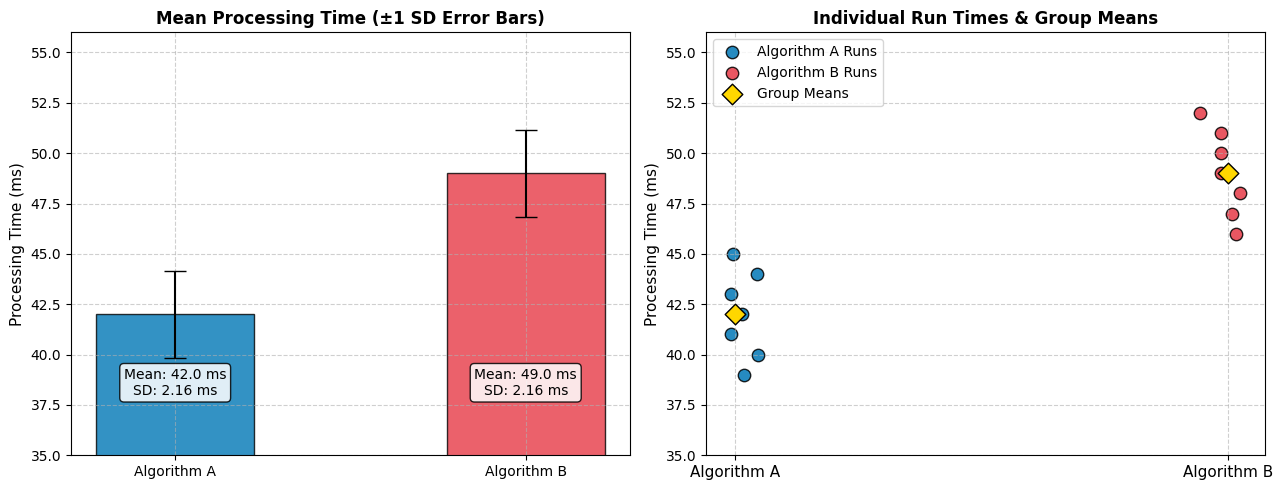

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Comparison of Mean Processing Times
algos = ['Algorithm A', 'Algorithm B']
means = [mean_a, mean_b]
stds = [std_a, std_b]
colors = ['#0077b6', '#e63946']

axes[0].bar(algos, means, yerr=stds, capsize=8, color=colors, alpha=0.8, edgecolor='black', width=0.45)
axes[0].set_title('Mean Processing Time (±1 SD Error Bars)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Processing Time (ms)', fontsize=11)
axes[0].set_ylim(35, 56)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Annotations
axes[0].text(0, 38, f"Mean: {mean_a:.1f} ms\nSD: {std_a:.2f} ms", ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85), fontsize=10)
axes[0].text(1, 38, f"Mean: {mean_b:.1f} ms\nSD: {std_b:.2f} ms", ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85), fontsize=10)

# Plot 2: Individual Measured Times
np.random.seed(42)
jitter_a = np.random.normal(0, 0.03, size=n_a)
jitter_b = np.random.normal(1, 0.03, size=n_b)

axes[1].scatter(jitter_a, algo_a, color='#0077b6', s=80, alpha=0.85, edgecolors='black', label='Algorithm A Runs')
axes[1].scatter(jitter_b, algo_b, color='#e63946', s=80, alpha=0.85, edgecolors='black', label='Algorithm B Runs')
axes[1].scatter([0, 1], means, color='gold', marker='D', s=110, edgecolors='black', zorder=5, label='Group Means')

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(algos, fontsize=11)
axes[1].set_title('Individual Run Times & Group Means', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Processing Time (ms)', fontsize=11)
axes[1].set_ylim(35, 56)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()
